# Identificação de Metástase com CNN (ResNet18) — Grupo 7

### Alunos

ANDREY DE OLIVEIRA SABINO 2025022571

JOÃO FELYPE FEITOSA REGO 2025022545

NATHAN CARDOSO LINHARES  2026010155

PEDRO VINICIUS DE ANDRADE QUEIROZ  2026010152

**Tema:** detecção de tecido metastático em histopatologia de linfonodos (dataset PatchCamelyon / PCam), usando transfer learning com ResNet18.

**Restrição:** roda sem GPU (apenas CPU). A estratégia é usar a ResNet18 já treinada na ImageNet como extrator de características congelado e treinar apenas uma cabeça classificadora sobre os vetores de 512 números.

Este notebook reúne todo o pipeline (antes dividido em 4 scripts):

1. Preparar um subconjunto balanceado do PCam
2. Extrair features com a ResNet18 congelada
3. Treinar a cabeça classificadora
4. Avaliar e gerar os gráficos (inline)

Antes de rodar, veja o `README.md` para instalação e onde colocar o dataset.

## 0. Configuração

Ajuste aqui o caminho do dataset e os hiperparâmetros. O código detecta sozinho se o dataset está no formato PCam (.h5) ou Kaggle (csv + .tif).

In [6]:
%matplotlib inline
from pathlib import Path
import numpy as np
import kagglehub

# Download do dataset (PatchCamelyon)
path = kagglehub.dataset_download("andrewmvd/metastatic-tissue-classification-patchcamelyon")
print("Path to dataset files:", path)

# Caminho do dataset
DIR_DADOS = Path(path)   # PCam .h5 ou Kaggle (csv + train/*.tif)

# Tamanho do subconjunto (balanceado 50/50)
N_TREINO, N_VAL, N_TESTE = 12000, 3000, 3000

# Pré-processamento
TAMANHO_IMG   = 96     # resolução de armazenamento (leve na RAM)
RESIZE_RESNET = 224    # resolução de entrada da ResNet (redimensionada por lote)

# Extração de features e treino
BATCH       = 64
NUM_WORKERS = 0        # Windows + Jupyter: use 0 para evitar travamento no DataLoader
EPOCAS      = 120      # com parada antecipada ele para sozinho
LR          = 1e-3
SEED        = 42

rng = np.random.default_rng(SEED)
print("Configuração carregada. Dataset esperado em:", DIR_DADOS)

Path to dataset files: C:\Users\Pedro Queiroz\.cache\kagglehub\datasets\andrewmvd\metastatic-tissue-classification-patchcamelyon\versions\9
Configuração carregada. Dataset esperado em: C:\Users\Pedro Queiroz\.cache\kagglehub\datasets\andrewmvd\metastatic-tissue-classification-patchcamelyon\versions\9


## 1. Preparar um subconjunto balanceado

Sorteamos um subconjunto 50% normal / 50% metástase dos splits oficiais do PCam (treino, validação e teste vêm de lâminas diferentes, sem vazamento de dados). As imagens ficam em memória (uint8), sem salvar em disco.

In [7]:
# Sorteia n índices, metade da classe 0 e metade da classe 1
def amostra_balanceada(labels, n):
    labels = np.asarray(labels).reshape(-1)
    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]
    k = n // 2
    if len(idx0) < k or len(idx1) < k:
        raise SystemExit(f"Poucas amostras: classe0={len(idx0)}, classe1={len(idx1)}, pedido={k} cada")
    sel0 = rng.choice(idx0, k, replace=False)
    sel1 = rng.choice(idx1, k, replace=False)
    sel = np.concatenate([sel0, sel1])
    rng.shuffle(sel)
    return sel


# Formato Kaggle (csv + .tif)
def carregar_kaggle(pasta):
    import pandas as pd
    from PIL import Image

    csv = pasta / "train_labels.csv"
    img_dir = pasta / "train"
    df = pd.read_csv(csv)  # colunas: id, label
    print(f"[Kaggle] {len(df)} imagens rotuladas. Distribuição: "
          f"{df['label'].value_counts().to_dict()}")

    total = N_TREINO + N_VAL + N_TESTE
    sel = amostra_balanceada(df["label"].values, total)
    df = df.iloc[sel].reset_index(drop=True)

    imgs = np.zeros((len(df), TAMANHO_IMG, TAMANHO_IMG, 3), dtype=np.uint8)
    for i, fid in enumerate(df["id"]):
        im = Image.open(img_dir / f"{fid}.tif").convert("RGB")
        if im.size != (TAMANHO_IMG, TAMANHO_IMG):
            im = im.resize((TAMANHO_IMG, TAMANHO_IMG))
        imgs[i] = np.asarray(im)
        if (i + 1) % 2000 == 0:
            print(f"  ...{i+1}/{len(df)} imagens lidas")
    return imgs, df["label"].values.astype(np.int64)


# Formato PCam oficial (.h5)
def _achar(pasta, padroes):
    for pad in padroes:
        achados = sorted(pasta.rglob(pad))
        if achados:
            return achados[0]
    return None


# Lê as imagens nos índices idx (ordenados) de um .h5 com chave 'x'
def _ler_x(caminho_x, idx):
    import h5py
    from PIL import Image
    idx = np.sort(idx)
    with h5py.File(caminho_x, "r") as h:
        raw = h["x"][idx]  # (n, 96, 96, 3) uint8
    if raw.shape[1] != TAMANHO_IMG:
        out = np.zeros((len(raw), TAMANHO_IMG, TAMANHO_IMG, 3), dtype=np.uint8)
        for i, im in enumerate(raw):
            out[i] = np.asarray(Image.fromarray(im).resize((TAMANHO_IMG, TAMANHO_IMG)))
        raw = out
    return raw, idx


def _ler_y(caminho_y):
    import h5py
    with h5py.File(caminho_y, "r") as h:
        return np.asarray(h["y"]).reshape(-1).astype(np.int64)


def carregar_pcam_oficial(pasta):
    mapa = {
        "treino": (["training_split.h5", "*train_x*.h5", "*split_train_x*.h5"],
                   ["*train_y*.h5", "*split_train_y*.h5"], N_TREINO),
        "val":    (["validation_split.h5", "*valid_x*.h5", "*split_valid_x*.h5"],
                   ["*valid_y*.h5", "*split_valid_y*.h5"], N_VAL),
        "teste":  (["test_split.h5", "*test_x*.h5", "*split_test_x*.h5"],
                   ["*test_y*.h5", "*split_test_y*.h5"], N_TESTE),
    }
    def ok_y(p):
        return p is not None and "mask" not in p.name.lower()

    resultado = {}
    for nome, (pad_x, pad_y, n) in mapa.items():
        fx = _achar(pasta, pad_x)
        fy = _achar(pasta, pad_y)
        if not ok_y(fy):
            cands = [c for c in sum([list(pasta.rglob(p)) for p in pad_y], []) if "mask" not in c.name.lower()]
            fy = sorted(cands)[0] if cands else None
        if fx is None or fy is None:
            return None
        y_all = _ler_y(fy)
        sel = amostra_balanceada(y_all, n)
        X, sel_ord = _ler_x(fx, sel)
        y = y_all[sel_ord]
        p = rng.permutation(len(X))
        resultado[nome] = (X[p], y[p])
        print(f"[PCam] {nome}: {fx.name} + {fy.name}  -> {X.shape}  classes={np.bincount(y).tolist()}")
    return resultado


# Detecta automaticamente o formato do dataset e carrega os splits
def detectar_e_carregar():
    p = DIR_DADOS
    if not p.exists():
        raise SystemExit(f"Pasta '{p}' não existe. Coloque o dataset lá (veja o README).")
    r = carregar_pcam_oficial(p)
    if r is not None:
        return r
    locais = [p] + [d for d in p.iterdir() if d.is_dir()]
    for loc in locais:
        if (loc / "train_labels.csv").exists():
            imgs, labels = carregar_kaggle(loc)
            a, b = N_TREINO, N_TREINO + N_VAL
            return {"treino": (imgs[:a], labels[:a]),
                    "val": (imgs[a:b], labels[a:b]),
                    "teste": (imgs[b:], labels[b:])}
    raise SystemExit("Não encontrei o dataset em formato conhecido (PCam .h5 ou Kaggle csv/tif).")


splits = detectar_e_carregar()
imgs_tr, y_tr = splits["treino"]
imgs_va, y_va = splits["val"]
imgs_te, y_te = splits["teste"]
print("\nPasso 1 OK -> treino:", imgs_tr.shape, "| val:", imgs_va.shape, "| teste:", imgs_te.shape)

[PCam] treino: training_split.h5 + camelyonpatch_level_2_split_train_y.h5  -> (12000, 96, 96, 3)  classes=[6000, 6000]
[PCam] val: validation_split.h5 + camelyonpatch_level_2_split_valid_y.h5  -> (3000, 96, 96, 3)  classes=[1500, 1500]
[PCam] teste: test_split.h5 + camelyonpatch_level_2_split_test_y.h5  -> (3000, 96, 96, 3)  classes=[1500, 1500]

Passo 1 OK -> treino: (12000, 96, 96, 3) | val: (3000, 96, 96, 3) | teste: (3000, 96, 96, 3)


## 2. Extrair features com a ResNet18 congelada

Passamos cada imagem uma única vez pela ResNet18 pré-treinada (ImageNet) e guardamos o vetor de 512 números. Como o backbone fica congelado, a parte cara (as convoluções) roda só uma vez e o treino depois é quase instantâneo na CPU.

In [8]:
import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, ResNet18_Weights
from tqdm.auto import tqdm

torch.manual_seed(SEED)
torch.set_num_threads(min(8, torch.get_num_threads() or 8))

# Normalização exata com que a ResNet foi treinada na ImageNet (precisa coincidir)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


# Guarda as imagens em uint8 e, só na hora de ler, redimensiona para 224,
# converte para float e normaliza (evita um tensor float gigante na RAM)
class DatasetImagens(Dataset):

    def __init__(self, imgs_uint8):
        self.imgs = imgs_uint8

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        x = torch.from_numpy(self.imgs[i]).permute(2, 0, 1).float() / 255.0
        if x.shape[1] != RESIZE_RESNET:
            x = F.interpolate(x.unsqueeze(0), size=RESIZE_RESNET,
                              mode="bilinear", align_corners=False).squeeze(0)
        return (x - MEAN) / STD


# ResNet18 pré-treinada, sem a camada fc. Saída = vetor de 512
def construir_extrator():
    pesos = ResNet18_Weights.IMAGENET1K_V1
    modelo = resnet18(weights=pesos)
    modelo.fc = torch.nn.Identity()   # remove o classificador de 1000 classes
    modelo.eval()                     # congela o BatchNorm
    for p in modelo.parameters():
        p.requires_grad = False       # congela todos os pesos
    return modelo


@torch.no_grad()
def extrair(modelo, imgs, nome):
    loader = DataLoader(DatasetImagens(imgs), batch_size=BATCH,
                        num_workers=NUM_WORKERS, shuffle=False)
    saidas = []
    for xb in tqdm(loader, desc=f"extraindo [{nome}]", unit="lote"):
        saidas.append(modelo(xb).cpu())
    return torch.cat(saidas).numpy().astype(np.float32)


print("Carregando ResNet18 pré-treinada (ImageNet) e congelando os pesos...")
extrator = construir_extrator()

t0 = time.time()
Xtr = extrair(extrator, imgs_tr, "treino")
Xva = extrair(extrator, imgs_va, "val")
Xte = extrair(extrator, imgs_te, "teste")
print(f"\nFeatures extraídas em {time.time()-t0:.1f}s -> treino {Xtr.shape}, val {Xva.shape}, teste {Xte.shape}")

# Libera RAM: não precisamos mais das imagens de treino/val (mantemos as de teste para exemplos)
del imgs_tr, imgs_va

Carregando ResNet18 pré-treinada (ImageNet) e congelando os pesos...


extraindo [treino]:   0%|          | 0/188 [00:00<?, ?lote/s]

extraindo [val]:   0%|          | 0/47 [00:00<?, ?lote/s]

extraindo [teste]:   0%|          | 0/47 [00:00<?, ?lote/s]


Features extraídas em 1638.5s -> treino (12000, 512), val (3000, 512), teste (3000, 512)


## 3. Treinar a cabeça classificadora

Modelo final = ResNet18 congelada (extrator) + cabeça treinável:

```
Linear(512 -> 256) -> BatchNorm -> ReLU -> Dropout(0.5)
Linear(256 -> 64)  -> BatchNorm -> ReLU -> Dropout(0.3)
Linear(64  -> 1)   -> Sigmoide
```

Treinamos só sobre os vetores de 512 números, então cada época leva frações de segundo. A parada antecipada pela AUC de validação evita overfitting.

In [9]:
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score

torch.manual_seed(SEED)
np.random.seed(SEED)

# Conversão das features para tensores
Xtr_t, ytr_t = torch.from_numpy(Xtr).float(), torch.from_numpy(y_tr).float()
Xva_t, yva_t = torch.from_numpy(Xva).float(), torch.from_numpy(y_va).float()
Xte_t, yte_t = torch.from_numpy(Xte).float(), torch.from_numpy(y_te).float()


# Implementando a cabeça classificadora
class Cabeca(nn.Module):

    def __init__(self, ent=512):

        super().__init__()

        self.rede = nn.Sequential(
            nn.Linear(ent, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):

        return self.rede(x).squeeze(1)


modelo = Cabeca(Xtr_t.shape[1])
opt  = torch.optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
crit = nn.BCEWithLogitsLoss()

# Parâmetros de treinamento
hist = {"perda_treino": [], "perda_val": [], "acc_val": [], "auc_val": []}
melhor_auc, melhor_estado, paciencia, espera = 0.0, None, 12, 0

# Treinamento
barra = tqdm(range(1, EPOCAS + 1), desc="Treinando", unit="epoca")
for ep in barra:

    # Modo de treinamento
    modelo.train()
    perm = torch.randperm(len(Xtr_t))
    perdas = []
    for i in range(0, len(Xtr_t), 256):
        idx = perm[i:i + 256]
        opt.zero_grad()
        loss = crit(modelo(Xtr_t[idx]), ytr_t[idx])
        loss.backward()
        opt.step()
        perdas.append(loss.item())

    # Modo de avaliação na validação
    modelo.eval()
    with torch.no_grad():
        logva = modelo(Xva_t)
        pva = torch.sigmoid(logva).numpy()
        perda_val = crit(logva, yva_t).item()
    acc_va = accuracy_score(y_va, pva > 0.5)
    auc_va = roc_auc_score(y_va, pva)
    hist["perda_treino"].append(float(np.mean(perdas)))
    hist["perda_val"].append(perda_val)
    hist["acc_val"].append(acc_va)
    hist["auc_val"].append(auc_va)
    barra.set_postfix(perda_tr=f"{np.mean(perdas):.3f}", perda_val=f"{perda_val:.3f}",
                      acc_val=f"{acc_va:.3f}", auc_val=f"{auc_va:.3f}")

    # Parada antecipada pela AUC de validação
    if auc_va > melhor_auc:
        melhor_auc = auc_va
        melhor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        espera = 0

    else:
        espera += 1

        # Critério de parada
        if espera >= paciencia:
            print(f"\nParada antecipada na época {ep} (sem melhora há {paciencia} épocas)")
            break

modelo.load_state_dict(melhor_estado)
print(f"Melhor AUC de validação: {melhor_auc:.4f}")

Treinando:   0%|          | 0/120 [00:00<?, ?epoca/s]


Parada antecipada na época 24 (sem melhora há 12 épocas)
Melhor AUC de validação: 0.9203


## 4. Avaliação final no conjunto de teste

O teste é usado só agora, no final, e mede o desempenho real em dados nunca vistos.

In [10]:
from sklearn.metrics import (confusion_matrix, roc_curve, precision_score,
                             recall_score, f1_score)

# Avaliação no conjunto de teste
modelo.eval()
with torch.no_grad():
    pte = torch.sigmoid(modelo(Xte_t)).numpy()
pred = (pte > 0.5).astype(int)

# Métricas
cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
met = {
    "acuracia": accuracy_score(y_te, pred),
    "auc": roc_auc_score(y_te, pte),
    "precisao": precision_score(y_te, pred),
    "recall_sensibilidade": recall_score(y_te, pred),
    "especificidade": tn / (tn + fp),
    "f1": f1_score(y_te, pred),
    "n_teste": int(len(y_te)),
    "melhor_epoca_auc_val": float(melhor_auc),
    "resolucao_entrada": RESIZE_RESNET,
}

# Resultados
print("===== Resultados no teste =====")
for k in ("acuracia", "auc", "precisao", "recall_sensibilidade", "especificidade", "f1"):
    print(f"  {k:22s}: {met[k]:.4f}")
print(f"\nMatriz de confusão -> VN={tn}  FP={fp}  FN={fn}  VP={tp}")
print("(FN = metástase não detectada = erro mais crítico em medicina)")

===== Resultados no teste =====
  acuracia              : 0.8233
  auc                   : 0.9062
  precisao              : 0.8825
  recall_sensibilidade  : 0.7460
  especificidade        : 0.9007
  f1                    : 0.8085

Matriz de confusão -> VN=1351  FP=149  FN=381  VP=1119
(FN = metástase não detectada = erro mais crítico em medicina)


## 5. Gráficos

Todos gerados inline, abaixo de cada célula.

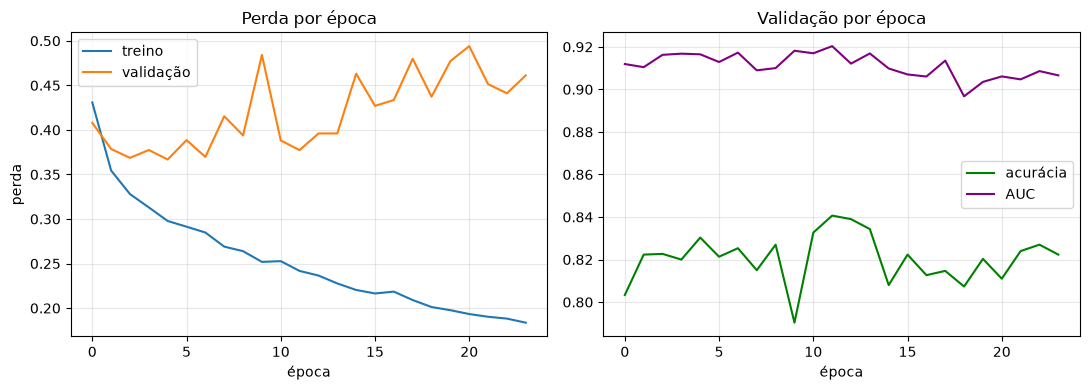

In [11]:
import matplotlib.pyplot as plt

# Curvas de treino
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(hist["perda_treino"], label="treino")
a1.plot(hist["perda_val"], label="validação")
a1.set_title("Perda por época"); a1.set_xlabel("época"); a1.set_ylabel("perda"); a1.legend(); a1.grid(alpha=.3)
a2.plot(hist["acc_val"], color="green", label="acurácia")
a2.plot(hist["auc_val"], color="purple", label="AUC")
a2.set_title("Validação por época"); a2.set_xlabel("época"); a2.legend(); a2.grid(alpha=.3)
fig.tight_layout(); plt.show()

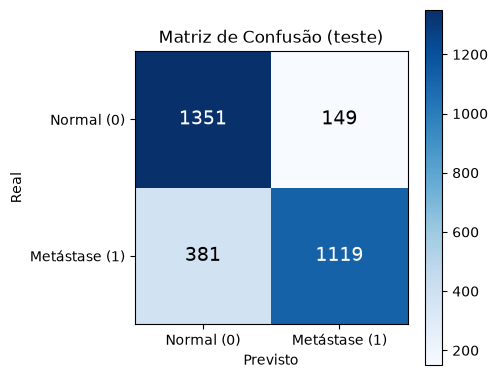

In [12]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4.3))
im = ax.imshow(cm, cmap="Blues")
rot = ["Normal (0)", "Metástase (1)"]
ax.set_xticks([0, 1], rot); ax.set_yticks([0, 1], rot)
ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title("Matriz de Confusão (teste)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
fig.colorbar(im); fig.tight_layout(); plt.show()

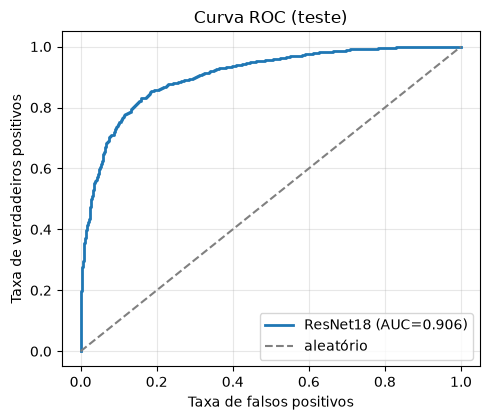

In [13]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_te, pte)
fig, ax = plt.subplots(figsize=(5, 4.3))
ax.plot(fpr, tpr, label=f"ResNet18 (AUC={met['auc']:.3f})", lw=2)
ax.plot([0, 1], [0, 1], "--", color="gray", label="aleatório")
ax.set_xlabel("Taxa de falsos positivos"); ax.set_ylabel("Taxa de verdadeiros positivos")
ax.set_title("Curva ROC (teste)"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

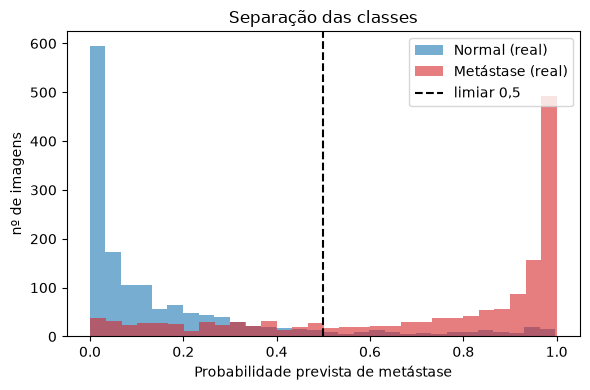

In [14]:
# Separação das classes (histograma)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pte[y_te == 0], bins=30, alpha=.6, label="Normal (real)", color="tab:blue")
ax.hist(pte[y_te == 1], bins=30, alpha=.6, label="Metástase (real)", color="tab:red")
ax.axvline(0.5, color="k", ls="--", label="limiar 0,5")
ax.set_xlabel("Probabilidade prevista de metástase"); ax.set_ylabel("nº de imagens")
ax.set_title("Separação das classes"); ax.legend()
fig.tight_layout(); plt.show()

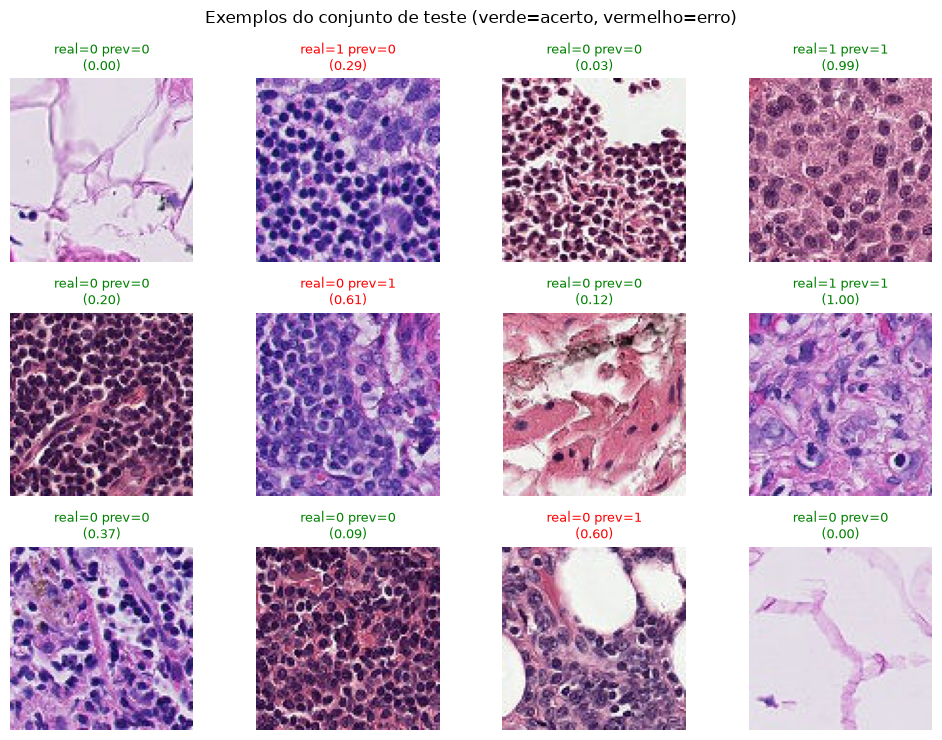

In [15]:
# Exemplos de previsões (patches reais do teste)
rng_ex = np.random.default_rng(0)
idx = rng_ex.choice(len(imgs_te), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(10, 7.5))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(imgs_te[i]); ax.axis("off")
    prob = pte[i]; pred_i = int(prob > 0.5); real = int(y_te[i])
    cor = "green" if pred_i == real else "red"
    ax.set_title(f"real={real} prev={pred_i}\n({prob:.2f})", color=cor, fontsize=9)
fig.suptitle("Exemplos do conjunto de teste (verde=acerto, vermelho=erro)")
fig.tight_layout(); plt.show()

## 6. (Opcional) Salvar os pesos da cabeça treinada

Caso queira reutilizar o modelo depois, sem retreinar.

In [16]:
# Salva os pesos da cabeça treinada
# torch.save(modelo.state_dict(), "cabeca_treinada.pt")
# print("Pesos salvos em cabeca_treinada.pt")